<a href="https://colab.research.google.com/github/VaishnaviSubramaniam08/Deep-Autoencoder-Based-Feature-Learning-for-Image-Classification/blob/main/DL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "puneet6060/intel-image-classification"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [2]:
import os

print(os.listdir(path))

['seg_train', 'seg_pred', 'seg_test']


In [3]:
import os

train_path = os.path.join(path, "seg_train", "seg_train")

print(os.listdir(train_path))

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [4]:
for class_name in os.listdir(train_path):

    class_path = os.path.join(train_path, class_name)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(class_name, ":", count)

mountain : 2512
street : 2382
buildings : 2191
sea : 2274
forest : 2271
glacier : 2404


In [5]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [8]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


In [9]:
normalization = tf.keras.layers.Rescaling(1./255)

In [10]:
train_ds = train_ds.map(
    lambda x, y: (normalization(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization(x), y)
)

In [11]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [12]:
from tensorflow.keras import layers, Model

input_img = layers.Input(
    shape=(128, 128, 3),
    name="input_image"
)

x = augmentation(input_img)

x = layers.Conv2D(
    32, 3,
    activation="relu",
    padding="same"
)(x)

x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(
    64, 3,
    activation="relu",
    padding="same"
)(x)

x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(
    128, 3,
    activation="relu",
    padding="same"
)(x)

x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

latent = layers.Conv2D(
    256,
    3,
    activation="relu",
    padding="same",
    name="latent_features"
)(x)

In [13]:
x = layers.Conv2D(
    128, 3,
    activation="relu",
    padding="same"
)(latent)

x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(
    64, 3,
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(
    32, 3,
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D(2)(x)

decoded = layers.Conv2D(
    3,
    3,
    activation="sigmoid",
    padding="same",
    name="reconstruction"
)(x)

In [14]:
autoencoder = Model(
    input_img,
    decoded,
    name="Deep_Autoencoder"
)

autoencoder.summary()

Model: "Deep_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Conv2D)        │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 777,475 (2.97 MB)

 Trainable params: 777,027 (2.96 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
ae_train = train_ds.map(
    lambda x, y: (x, x)
)

ae_val = val_ds.map(
    lambda x, y: (x, x)
)

In [16]:
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse"
)

In [17]:
history_ae = autoencoder.fit(
    ae_train,
    validation_data=ae_val,
    epochs=30
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 132ms/step - loss: 0.0390 - val_loss: 0.0344
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - loss: 0.0363 - val_loss: 0.0247
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - loss: 0.0359 - val_loss: 0.0234
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - loss: 0.0353 - val_loss: 0.0239
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - loss: 0.0348 - val_loss: 0.0241
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - loss: 0.0346 - val_loss: 0.0240
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - loss: 0.0344 - val_loss: 0.0237
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - loss: 0.0339 - val_loss: 0.0247
Epoch 9/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - loss: 0.0338 - val_loss: 0.0211
Epoch 10/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - loss: 0.0339 - val_loss: 0.0221
Epoch 11/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - loss: 0.0335 - val_loss: 0.0206
Epoch 12/30
351/351 ━━━━━━━━━

In [34]:
autoencoder.save("deep_autoencoder.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


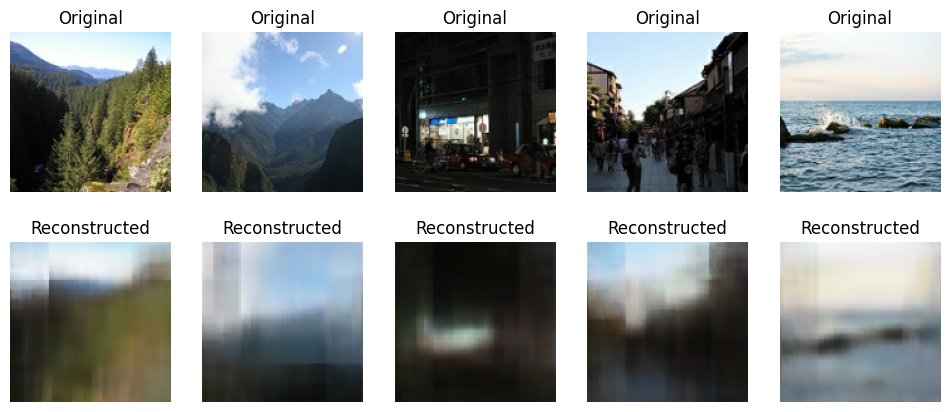

In [18]:
import matplotlib.pyplot as plt

for images, _ in ae_val.take(1):

    reconstructed = autoencoder.predict(images)

    plt.figure(figsize=(12, 5))

    for i in range(5):

        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
        plt.title("Original")

        plt.subplot(2, 5, i + 6)
        plt.imshow(reconstructed[i])
        plt.axis("off")
        plt.title("Reconstructed")

    plt.show()

In [19]:
encoder = Model(
    input_img,
    latent,
    name="Feature_Encoder"
)

encoder.summary()

Model: "Feature_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Conv2D)        │ (None, 16, 16, 256)    │       295,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,312 (1.49 MB)

 Trainable params: 388,864 (1.48 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
classifier_input = layers.Input(
    shape=(128, 128, 3),
    name="classifier_input"
)

features = encoder(classifier_input)

features = layers.GlobalAveragePooling2D()(features)

features = layers.Dense(
    256,
    activation="relu"
)(features)

features = layers.Dropout(0.4)(features)

output = layers.Dense(
    6,
    activation="softmax",
    name="classification"
)(features)

classifier = Model(
    classifier_input,
    output,
    name="Autoencoder_Classifier"
)

In [21]:
encoder.trainable = False

In [22]:
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history_classifier = classifier.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.6144 - loss: 1.0032 - val_accuracy: 0.7213 - val_loss: 0.7433
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7059 - loss: 0.7885 - val_accuracy: 0.7341 - val_loss: 0.7039
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7365 - loss: 0.7190 - val_accuracy: 0.7655 - val_loss: 0.6494
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7462 - loss: 0.6912 - val_accuracy: 0.7823 - val_loss: 0.6073
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7566 - loss: 0.6638 - val_accuracy: 0.7855 - val_loss: 0.6122
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7602 - loss: 0.6538 - val_accuracy: 0.7887 - val_loss: 0.5943
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7660 - loss: 0.6357 - val_accuracy: 0.7872 - val_loss: 0.5974
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7725 - loss: 0.6166 - 

In [35]:
classifier.save("autoencoder_classifier.keras")

In [24]:
encoder.trainable = True

In [25]:
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history_finetune = classifier.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.7878 - loss: 0.5794 - val_accuracy: 0.7994 - val_loss: 0.5697
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.7942 - loss: 0.5483 - val_accuracy: 0.8004 - val_loss: 0.5651
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.8046 - loss: 0.5369 - val_accuracy: 0.8019 - val_loss: 0.5550
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.8058 - loss: 0.5302 - val_accuracy: 0.7994 - val_loss: 0.5588
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.8138 - loss: 0.5142 - val_accuracy: 0.8022 - val_loss: 0.5473
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.8115 - loss: 0.5164 - val_accuracy: 0.7986 - val_loss: 0.5493
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.8119 - loss: 0.5045 - val_accuracy: 0.8015 - val_loss: 0.5504
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.8189 - loss: 0.4993 - 

In [29]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = classifier.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

In [30]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.75      0.79      0.77       430
      forest       0.89      0.97      0.93       436
     glacier       0.80      0.72      0.76       473
    mountain       0.83      0.70      0.76       514
         sea       0.77      0.86      0.82       477
      street       0.81      0.82      0.81       476

    accuracy                           0.81      2806
   macro avg       0.81      0.81      0.81      2806
weighted avg       0.81      0.81      0.81      2806



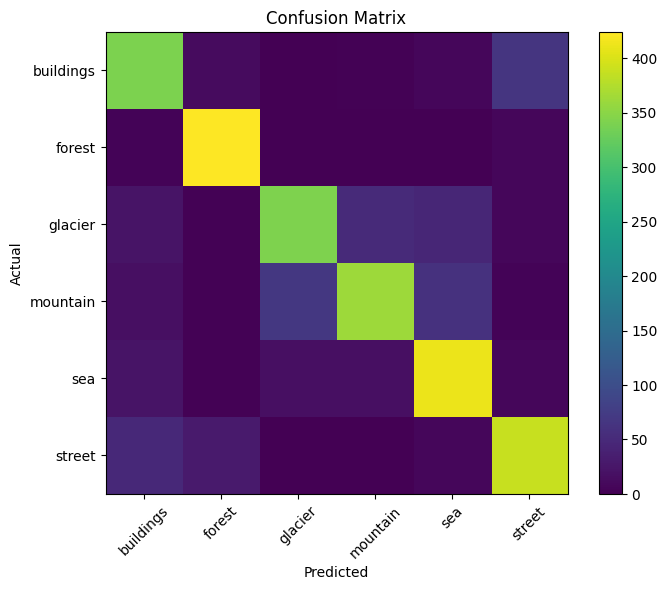

In [31]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(6),
    class_names,
    rotation=45
)

plt.yticks(
    range(6),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [32]:
from tensorflow.keras.utils import load_img, img_to_array

img = load_img(
    "my_image.jpg",
    target_size=(128, 128)
)

img_array = img_to_array(img) / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

In [33]:
prediction = classifier.predict(img_array)

predicted_class = np.argmax(prediction[0])

print(
    "Predicted class:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    prediction[0][predicted_class]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Predicted class: sea
Confidence: 0.89554244


In [36]:
from google.colab import files

files.download("autoencoder_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
files.download("deep_autoencoder.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
from tensorflow.keras.models import load_model

model = load_model("autoencoder_classifier.keras")

In [39]:
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction[0])

print("Predicted class:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
Predicted class: sea


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model

print("TensorFlow version:")
print(tf.__version__)

autoencoder = tf.keras.models.load_model(
    "deep_autoencoder.keras",
    compile=False
)

print("AUTOENCODER LOADED SUCCESSFULLY")

print("\nAUTOENCODER LAYERS")
print("=" * 60)

for layer in autoencoder.layers:
    print(
        layer.name,
        "->",
        type(layer).__name__
    )

TensorFlow version:
2.20.0


ValueError: File not found: filepath=deep_autoencoder.keras. Please ensure the file is an accessible `.keras` zip file.